In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from netCDF4 import Dataset

import iris
import iris.coord_categorisation
import iris.plot as iplt
import iris.quickplot as qplt

import os
import logging

import numpy as np
import numpy.ma as ma

import pickle
from pathlib import Path

from IPython.display import clear_output
import gc

logger = logging.getLogger(__name__)


In [2]:
def average_dict(input):
    output=sum( np.array(input[clim] )[0][:] for clim in ESMS) / 3
    return(output)

In [9]:
def get_global_biophys_noiris(var,landuse,model,ssp,mask_landuse):
    ESMS=['mpi-esm1-2-hr','ukesm1-0-ll','ipsl-cm6a-lr']  
    path = '' 

    if model=='jules' and landuse=='noluc':
        landuse='nolucbio'
    
    nclim = len(ESMS)
    
    if model=='jsbach':
     years = np.arange(2015,2100)
    else:
     years = np.arange(2015,2101)   
    nyears = len(years)
    nmonths= nyears*12

    land_fraction,lons,lats = get_lsm_data(model)
    nlat = len(lats)
    nlon = len(lons)
    weights = np.empty_like(land_fraction)
    bph_annual = np.zeros([3,nyears])
    
    if model!= 'jsbach':
        for kk in range(nlat):
            weights[kk,0:nlon] = np.cos(np.deg2rad(lats[kk])) * land_fraction[kk,0:nlon]
    else:
        for kk in range(nlat):
            weights[kk,0:nlon] = np.cos(np.deg2rad(lats[kk]))       
    weights_3d = np.stack([weights] * nyears)
    #print(weights_3d.shape)

    # 3 per SSP
    filenames = get_filenames(var,landuse,model,ssp)
    
    model_i=0
    for fname in filenames:    
        ncfile2=Dataset(fname, 'r')
        #print(fname)
        mon_data = ncfile2.variables[var]
        #print(mon_data)
        #print(mon_data.missing_value)
        if model!='clm':
            mon_data = np.ma.masked_values(mon_data, mon_data.missing_value, True)
        else:
            mon_data = np.ma.masked_greater(mon_data, 1.0e30, True)   
                      
        if mask_landuse:
            monthly_mean = get_lsm_fracs(mon_data,mon_data,model,ESMS[model_i],ssp,landuse,False,False)

        
        #print('monthly data:',mon_data.shape,np.min(mon_data),np.max(mon_data))
        #print('check resizing:',mon_data.reshape((nyears,12,nlat,nlon)).shape)
        annual_data = np.mean(monthly_mean.reshape((nyears,12,nlat,nlon)),axis=1)
        print('annual data:',ESMS[model_i],ssp,annual_data.shape,np.min(annual_data),np.max(annual_data))
        
        bph_annual[model_i,:] = np.mean(annual_data*weights_3d,axis=(1,2))
        #print(bph_annual[model_i,:])
        model_i+=1   
        del(mon_data, monthly_mean, annual_data)
    
    #print(np.mean(bph_annual,axis=0))

    return np.mean(bph_annual,axis=0)

In [16]:
def get_global_biophys_delta(var,landuse,model,ssp,noluc_only):
    ESMS=['mpi-esm1-2-hr','ukesm1-0-ll','ipsl-cm6a-lr']  
    path = '' 

    nclim = len(ESMS)
    
    if model=='jsbach':
     years = np.arange(2015,2100)
    else:
     years = np.arange(2015,2101)   
    nyears = len(years)
    nmonths= nyears*12

    land_fraction,lons,lats = get_lsm_data(model)
    nlat = len(lats)
    nlon = len(lons)
    weights = np.empty_like(land_fraction)
    bph_annual = np.zeros([3,nyears])  
    
    if model!= 'jsbach':
        for kk in range(nlat):
            weights[kk,0:nlon] = np.cos(np.deg2rad(lats[kk])) * land_fraction[kk,0:nlon]
    else:
        for kk in range(nlat):
            weights[kk,0:nlon] = np.cos(np.deg2rad(lats[kk]))       
    weights_3d = np.stack([weights] * nyears)
    #print(weights_3d.shape)

    # 3 per SSP
    filenames = get_filenames(var,landuse,model,ssp)
    if model=='jules':
        filenames_noluc = get_filenames(var,'nolucbio',model,ssp)
    else:
        filenames_noluc = get_filenames(var,'noluc',model,ssp)
    model_i=0

    for fname in filenames:    
        ncfile=Dataset(fname, 'r')
        mon_data = ncfile.variables[var]
        if model!='clm':
            mon_data = np.ma.masked_values(mon_data, mon_data.missing_value, True)
        else:
            #print('CLM before first mask:',np.min(mon_data),np.max(mon_data))
            mon_data = np.ma.masked_greater(mon_data, 1.0e30, True)   
            #print('CLM after first mask:',np.min(mon_data),np.max(mon_data))
              
        ncfile2=Dataset(filenames_noluc[model_i],'r')
        noluc_data = ncfile2.variables[var]
        if model!='clm':
            noluc_data = np.ma.masked_values(noluc_data, noluc_data.missing_value, True)
        else:
            noluc_data = np.ma.masked_greater(noluc_data, 1.0e30, True)   
        if noluc_only:
            calc_delta=False
        else:    
            calc_delta=True
        monthly_delta = get_lsm_fracs(mon_data,noluc_data,model,ESMS[model_i],ssp,landuse,calc_delta,noluc_only)
        print(np.min(monthly_delta),np.max(monthly_delta))
        annual_delta = np.mean(monthly_delta.reshape((nyears,12,nlat,nlon)),axis=1)
        
        bph_annual[model_i,:] = np.mean(annual_delta*weights_3d,axis=(1,2))
        model_i+=1   
        del(monthly_delta, annual_delta)
    
    #print(model,np.mean(map_2015,axis=0),np.mean(map_2100,axis=0))
    #print(np.mean(bph_annual,axis=0))

    return np.mean(bph_annual,axis=0)

In [5]:
run plot_tools.ipynb

Done with rn jules agtobio
Done with rn jules nattobio
Done with rn jsbach agtobio
Done with rn jsbach nattobio
Done with hfss jules agtobio
Done with hfss jules nattobio
Done with hfss clm agtobio
Done with hfss clm nattobio
Done with hfss jsbach agtobio
Done with hfss jsbach nattobio
Done with hfls jules agtobio
Done with hfls jules nattobio
Done with hfls clm agtobio
Done with hfls clm nattobio
Done with hfls jsbach agtobio
Done with hfls jsbach nattobio
Done with hfg clm agtobio
Done with hfg clm nattobio
Done with hfg jsbach agtobio
Done with hfg jsbach nattobio
Done with rlds clm agtobio
Done with rlds clm nattobio
Done with rlds jsbach agtobio
Done with rlds jsbach nattobio
Done with rlus clm agtobio
Done with rlus clm nattobio
Done with rsds jules agtobio
Done with rsds jules nattobio
Done with rsds clm agtobio
Done with rsds clm nattobio
Done with rsds jsbach agtobio
Done with rsds jsbach nattobio
Done with rsus clm agtobio
Done with rsus clm nattobio
Done with rsus jsbach agt

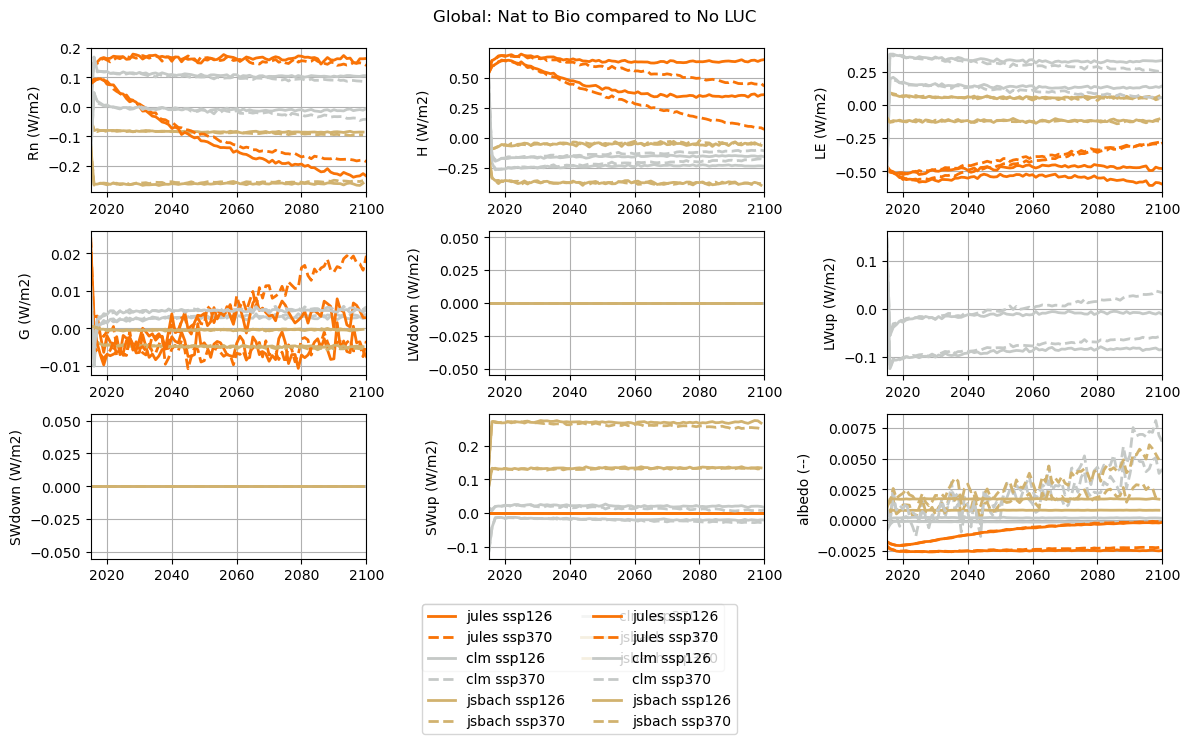

In [32]:
#DELTA CALCULATIONS:

#For each land use scenario, calculate the difference between the scenario and 
#no luc ONLY IN GRID CELLS WITH BE CROPS. This is the 'delta'. Calculate 
#global means from the delta.

MODELS=['jules','clm','jsbach']
LANDUSES=['agtobio','nattobio']
SSPS=['ssp126','ssp370']
ESMS=['mpi-esm1-2-hr','ukesm1-0-ll','ipsl-cm6a-lr']
VARIABLES=['rn','hfss','hfls',\
           'hfg','rlds','rlus',\
           'rsds','rsus','TotalAlbedo']

# Note: Temperature variables for each model:
# JULES      tas, tsl (soil level), tskinpft
# JSBACH     tas, tsl
# CLM        tsl (but meta data says its tskin), and tskinpft)
# ORCHIDEE   no temperature data.

#How close can we get to energy balance for each model:
# X means it's missing
#        Rn    =   SH +    L + g          = SWdown  -  Swup      + LWdown - LWup
#JULES   rn    = hfss + hfls + X          = TotalAlbedo*(SWdown) + X      - X
#JSBACH  rn    = sfls + hfls + fGoundHeat = rsds    - rsus       + rlds   - X
#CLM     X     = hfss + rfls + hfg        = rsds    - rsus       + rlds   - rlus

years = np.arange(2015,2101)     
nyears = len(years)

all_landuse=['noluc_agtobio','noluc_nattobio','agtobio','nattobio']
DELTA_GLOBAL = {var: {lsm_mod: {landuse: {ssp_scen: [] for ssp_scen in SSPS} 
                    for landuse in LANDUSES} for lsm_mod in MODELS} 
                    for var in VARIABLES}
GLOBAL_MEAN = {var: {lsm_mod: {landuse: {ssp_scen: [] for ssp_scen in SSPS} 
                    for landuse in all_landuse} for lsm_mod in MODELS} 
                    for var in VARIABLES}
landuse_exists = {lsm_mod: {landuse: [True] for landuse in LANDUSES} for lsm_mod in MODELS}

variable_exists = {var: {lsm_mod: [True] for lsm_mod in MODELS} for var in VARIABLES}
variable_exists['TotalAlbedo']['jsbach'] = False
variable_exists['TotalAlbedo']['clm'] = False
variable_exists['rn']['clm'] = False
variable_exists['hfg']['jules'] = False
variable_exists['rlus']['jules'] = False
variable_exists['rsus']['jules'] = False
variable_exists['rlus']['jsbach'] = False
variable_exists['rlds']['jules'] = False

test_mean={ssp: [] for ssp in SSPS}
colors = {model: [] for model in MODELS}
colors['jules'] = '#F97306'
colors['clm'] = '#C5C9C7'
colors['jsbach'] = '#D1B26F'
#colors['orchidee'] = '#A9561E'
#https://matplotlib.org/stable/users/explain/colors/colors.html

linestyles = {ssp: [] for ssp in SSPS}
linestyles['ssp126'] = '-'
linestyles['ssp370'] = '--'

for var in VARIABLES:
    for model in MODELS:
        if variable_exists[var][model]:
            #print('Get ',var,model)
            for landuse in LANDUSES:
                if model=='jules' and var=='hfls':
                    varname='fHeatLatent'
                elif model=='jules' and var=='hfss':
                    varname='fHeatSensible'
                elif model=='jsbach' and var=='hfss':
                    varname='sfls'
                elif model=='jsbach' and var=='hfg':
                    varname='fGroundHeat'
                else:
                    varname=var
                        
                pickle_file=['/bdd/ESM2025/WP10/analysis/files/'+model+'_ssp126_delta'+var+'_'+landuse+'_BEmasked.pkl',\
                            '/bdd/ESM2025/WP10/analysis/files/'+model+'_ssp370_delta'+var+'_'+landuse+'_BEmasked.pkl']
                # First get the no land use outputs, masked according to the landuse scenario
                if Path(pickle_file[0]).is_file():
                    #print(landuse,'read pickle files',pickle_file[0])
                    with open(Path(pickle_file[0]), 'rb') as f1:
                        ssp126_output = pickle.load(f1)
                    with open(Path(pickle_file[1]), 'rb') as f2:
                        ssp370_output = pickle.load(f2)
                    DELTA_GLOBAL[var][model][landuse]['ssp126'] = ssp126_output
                    DELTA_GLOBAL[var][model][landuse]['ssp370'] = ssp370_output
                    del(ssp126_output, ssp370_output)
                else:
                    noluc_only=False
                    DELTA_GLOBAL[var][model][landuse]['ssp126'] = \
                                 get_global_biophys_delta(varname,landuse,model,'ssp126',noluc_only)
                    DELTA_GLOBAL[var][model][landuse]['ssp370'] = \
                                 get_global_biophys_delta(varname,landuse,model,'ssp370',noluc_only)                     
                    with open(Path(pickle_file[0]), 'wb') as f1:
                        pickle.dump(DELTA_GLOBAL[var][model][landuse]['ssp126'], f1)
                    with open(Path(pickle_file[1]), 'wb') as f2:
                        pickle.dump(DELTA_GLOBAL[var][model][landuse]['ssp370'], f2)
                print('Done with',var,model,landuse)
                
# FIRST PLOT THE NO LAND USE CHANGE SCENARIO.

#These will be calculated
variable_exists['TotalAlbedo']['jsbach'] = True
variable_exists['TotalAlbedo']['clm'] = True
variable_exists['rn']['clm'] = True
variable_exists['hfg']['jules'] = True
variable_exists['rsus']['jules'] = True

#Set up plotting stuff
#Each land model needs a different color
fig,axes=plt.subplots(3,3, figsize=[12,6])

for landuse in LANDUSES:
    if landuse=='agtobio':
        fig.suptitle('Global: Ag to Bio compared to No LUC',fontsize=12)
    elif landuse=='nattobio':
        fig.suptitle('Global: Nat to Bio compared to No LUC',fontsize=12)
    icol=0
    irow=0
    for var in VARIABLES:
        # set axes
        ax=axes[irow,icol]
        if var=='tas': ax.set_ylabel(r'$\Delta$' +var+' (K) ',fontsize=10)
        if var=='hfss': ax.set_ylabel('H (W/m2) ',fontsize=10)
        if var=='hfls': ax.set_ylabel('LE (W/m2) ',fontsize=10)
        if var=='hfg': ax.set_ylabel('G (W/m2) ',fontsize=10)
        if var=='rn': ax.set_ylabel('Rn (W/m2) ',fontsize=10)
        if var=='rsus': ax.set_ylabel('SWup (W/m2)',fontsize=10)
        if var=='rsds': ax.set_ylabel('SWdown (W/m2)',fontsize=10)
        if var=='rlus': ax.set_ylabel('LWup (W/m2)',fontsize=10)
        if var=='rlds': ax.set_ylabel('LWdown (W/m2)',fontsize=10)        
        if var=='TotalAlbedo': ax.set_ylabel('albedo (--) ',fontsize=10)
        ax.set_xlim([2015,2100])
        ax.grid(True) 

        for model in MODELS:
            if variable_exists[var][model]:
                if model=='jsbach':
                    endyear=nyears-1
                else:
                    endyear=nyears      
                
                for ssp in SSPS:
                    print(var,model,ssp)
                    if var =='TotalAlbedo':
                        if model=='jules':
                            # This is actually TotalAlbedo already
                            plot_noluc=(DELTA_GLOBAL[var][model][landuse][ssp]) 
                        else:
                            pfiles=['/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_rsus_'+landuse+'_BEmasked.pkl',\
                                '/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_rsds_'+landuse+'_BEmasked.pkl',\
                                '/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_rsus_noluc_'+landuse+'_masked.pkl',\
                                '/bdd/ESM2025/WP10/analysis/files/'+model+'_'+ssp+'_rsds_noluc_'+landuse+'_masked.pkl']
                            #Files 0 and 1 already exist
                            with open(Path(pfiles[0]), 'rb') as f1:
                                GLOBAL_MEAN['rsus'][model][landuse][ssp] = pickle.load(f1)
                            with open(Path(pfiles[1]), 'rb') as f2:
                                GLOBAL_MEAN['rsds'][model][landuse][ssp] = pickle.load(f2)
                            
                            if Path(pfiles[3]).is_file():
                                with open(Path(pfiles[2]), 'rb') as f3:
                                    GLOBAL_MEAN['rsus'][model]['noluc_'+landuse][ssp] = pickle.load(f3)
                                with open(Path(pfiles[3]), 'rb') as f4:
                                    GLOBAL_MEAN['rsds'][model]['noluc_'+landuse][ssp] = pickle.load(f4)
                            else:
                                noluc_only=True
                                GLOBAL_MEAN['rsus'][model]['noluc_'+landuse][ssp] = \
                                    get_global_biophys_delta('rsus',landuse,model,ssp,noluc_only)
                                GLOBAL_MEAN['rsds'][model]['noluc_'+landuse][ssp] = \
                                    get_global_biophys_delta('rsds',landuse,model,ssp,noluc_only)
                                with open(Path(pfiles[2]), 'wb') as f3:
                                    pickle.dump(GLOBAL_MEAN['rsus'][model]['noluc_'+landuse][ssp], f3)
                                with open(Path(pfiles[3]), 'wb') as f4:
                                    pickle.dump(GLOBAL_MEAN['rsds'][model]['noluc_'+landuse][ssp], f4)
                                                    
                            #Convert this to albedo.
                            print('save albedo',var,model,landuse,ssp)
                            DELTA_GLOBAL[var][model][landuse][ssp] = (GLOBAL_MEAN['rsus'][model][landuse][ssp] / \
                                    GLOBAL_MEAN['rsds'][model][landuse][ssp]) - \
                                    (GLOBAL_MEAN['rsus'][model]['noluc_'+landuse][ssp] / \
                                     GLOBAL_MEAN['rsds'][model]['noluc_'+landuse][ssp] )
                            plot_noluc = DELTA_GLOBAL[var][model][landuse][ssp]

                
                            #print(GLOBAL_MEAN['rsus'][model][landuse][ssp][0],\
                            #      GLOBAL_MEAN['rsds'][model][landuse][ssp][0],\
                            #      GLOBAL_MEAN['rsds'][model]['noluc_'+landuse][ssp][0])
                            #      GLOBAL_MEAN['rsus'][model]['noluc_'+landuse][ssp][0],\
                    elif var=='rn' and model=='clm':
                        plot_noluc=(DELTA_GLOBAL['hfss'][model][landuse][ssp])+ \
                               (DELTA_GLOBAL['hfls'][model][landuse][ssp])+ \
                               (DELTA_GLOBAL['hfg'][model][landuse][ssp])
                    elif var=='hfg' and model=='jules':
                        plot_noluc=(DELTA_GLOBAL['rn'][model][landuse][ssp])- \
                               (DELTA_GLOBAL['hfls'][model][landuse][ssp])- \
                               (DELTA_GLOBAL['hfss'][model][landuse][ssp])
                    elif var=='rsus' and model=='jules':
                        plot_noluc=(DELTA_GLOBAL['rsds'][model][landuse][ssp])* \
                               (DELTA_GLOBAL['TotalAlbedo'][model][landuse][ssp])
                    else:
                        plot_noluc=DELTA_GLOBAL[var][model][landuse][ssp]
                
                    #print(var,model)
                    #print(plot_noluc,np.min(plot_noluc),np.max(plot_noluc))
                    ax.plot(years[:endyear], plot_noluc, label=model+' '+ssp,
                            c=colors[model],ls=linestyles[ssp],lw=2) 
                    #print(var,model,landuse,ssp,plot_noluc[endyear-1])


        icol+=1
        if icol>2:
            icol=0
            irow+=1

    ax=axes[0,0]
    handles,labels = ax.get_legend_handles_labels()
    fig.legend(handles,labels,ncol=2,loc='upper left',bbox_to_anchor=(0.35, 0.0),fontsize=10)
    fig.tight_layout()

    plt.savefig('/bdd/ESM2025/WP10/plots/biophys_delta'+landuse+'_Global.png', format="png")

new plot: agtobio
agtobio TotalAlbedo jules ssp126
[-0.00207248 -0.00230023 -0.00241119 -0.00251059 -0.00254135 -0.00252813
 -0.0025618  -0.00255215 -0.00254854 -0.0025507  -0.0025489  -0.00254028
 -0.00254496 -0.00257352 -0.0025752  -0.00256149 -0.00250918 -0.00252765
 -0.00254672 -0.00255536 -0.00254582 -0.00252657 -0.0025321  -0.00252012
 -0.00250862 -0.00248524 -0.00253167 -0.00253674 -0.00249843 -0.00250353
 -0.00247203 -0.00248361 -0.00247045 -0.00243702 -0.00245686 -0.00247421
 -0.00245245 -0.00247831 -0.00245227 -0.00247212 -0.0024831  -0.00250641
 -0.00249305 -0.00245872 -0.00249947 -0.0024687  -0.00245749 -0.00245551
 -0.00248979 -0.0024606  -0.00244555 -0.00245692 -0.00247736 -0.0024472
 -0.00244836 -0.00244231 -0.00242455 -0.00247778 -0.00245692 -0.00243257
 -0.00244922 -0.00245609 -0.00243091 -0.00246749 -0.00244567 -0.00248369
 -0.00248557 -0.00244864 -0.0024449  -0.00246191 -0.00246707 -0.00240348
 -0.00244742 -0.00244862 -0.00244424 -0.00244495 -0.00245993 -0.00246186
 

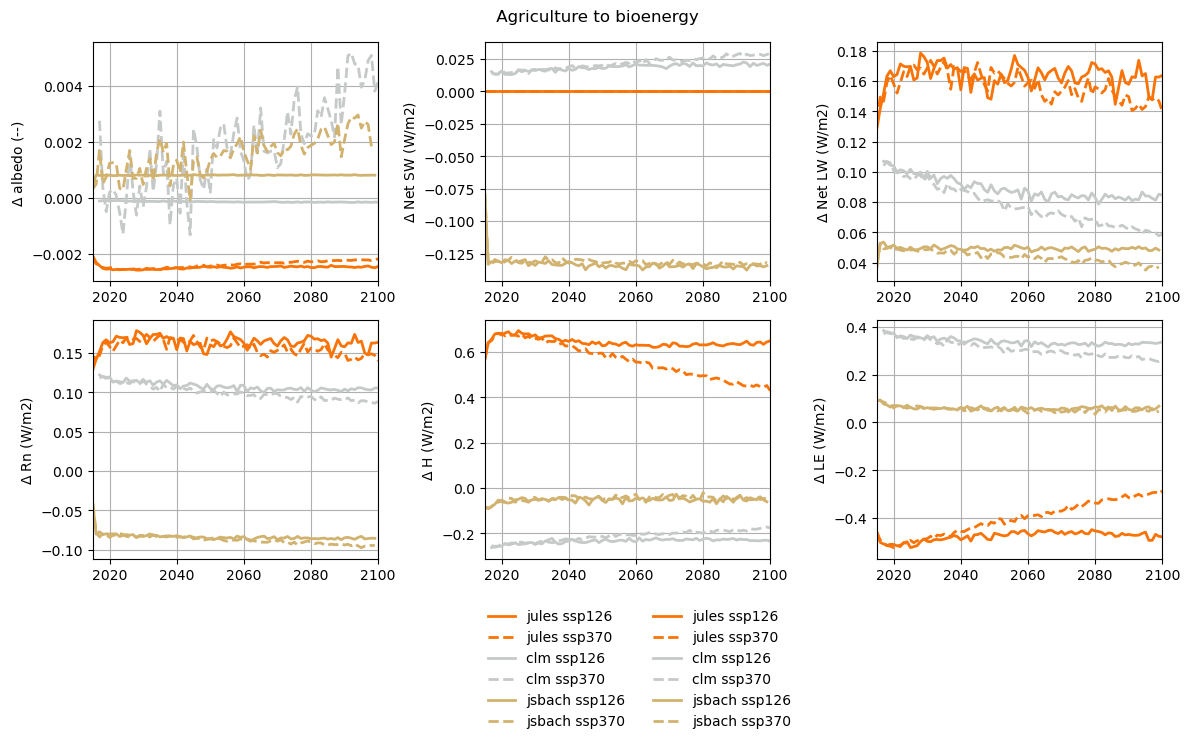

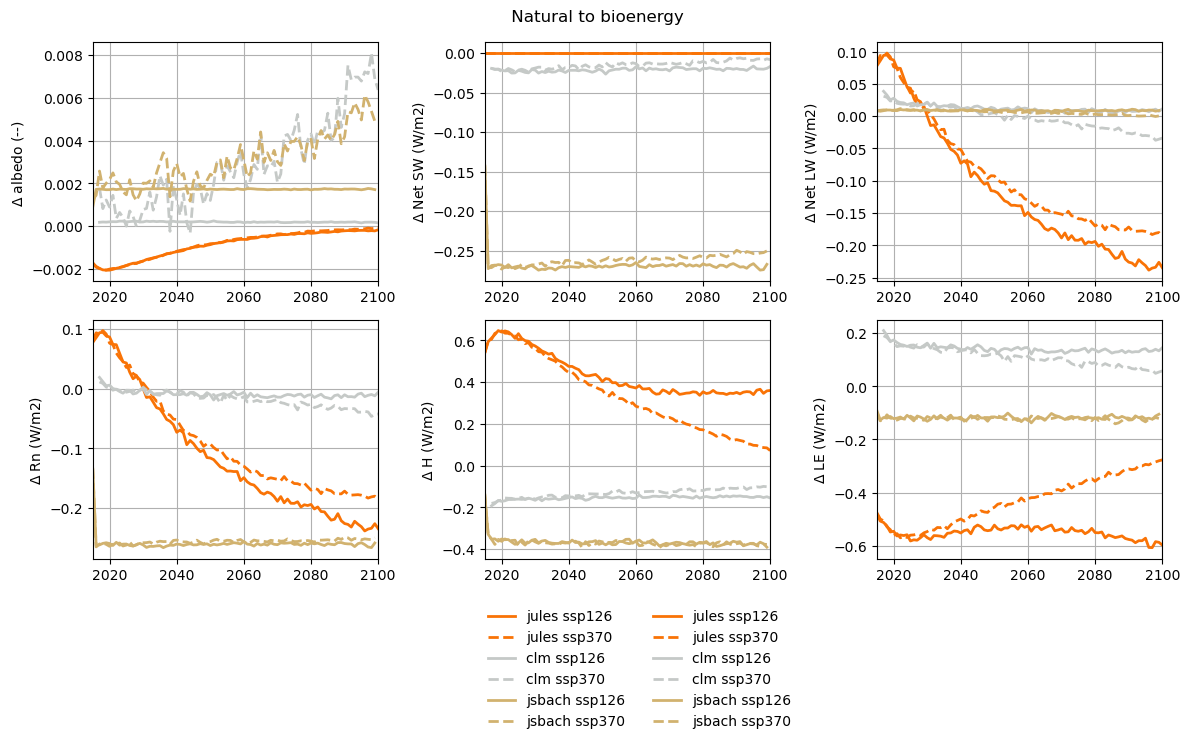

In [33]:
# PLOT THE LANDUSE SCENARIO DIFFERENCE FROM THE NOLUC SCENARIO

landuse_title=[' Agriculture to bioenergy', ' Natural to bioenergy']

# We don't need to plot all the same variables because some are the same
# regardless of the land use scenario (rlds and rsds).
# rlus is only available for one model, not interesting, and is a fx of tas
# 
VARIABLES=['TotalAlbedo','SWnet','LWnet',\
           'rn',\
           'hfss','hfls']   

#VARIABLES=['rn','SWnet','LWnet','tas']
#Note: 'tas' in CLM is actually skin T, and this makes it difficult to compare to 
# actual air temperature in JSBACH and JULES. I will remove this from the analysis
# and focus on overall change in net radiation, and how it is partitioned between 
# LE and H.
i1=0
for landuse in LANDUSES:
    #Set up plotting stuff
    #Each land use scenario has a new figure
    print('new plot:',landuse)
    fig2,axes2=plt.subplots(2,3, figsize=[12,6])
    fig2.suptitle(landuse_title[i1],fontsize=12)    
    irow=0
    icol=0
        
    for var in VARIABLES:
        # set axes
        ax=axes2[irow,icol]
        if var=='hfss': ax.set_ylabel(r'$\Delta$ H (W/m2) ',fontsize=10)
        if var=='hfls': ax.set_ylabel(r'$\Delta$ LE (W/m2) ',fontsize=10)
        if var=='rn': ax.set_ylabel(r'$\Delta$ Rn (W/m2) ',fontsize=10)
        if var=='SWnet': ax.set_ylabel(r'$\Delta$ Net SW (W/m2)',fontsize=10)
        if var=='LWnet': ax.set_ylabel(r'$\Delta$ Net LW (W/m2)',fontsize=10)      
        if var=='TotalAlbedo': ax.set_ylabel(r'$\Delta$ albedo (--) ',fontsize=10)        
            
        ax.set_xlim([2015,2100])
        ax.grid(True) 
        
        for model in MODELS:
            if model=='jsbach':
                endyear=nyears-1
            else:
                endyear=nyears

            for ssp in SSPS:
                print(landuse,var,model,ssp)
                if var =='TotalAlbedo':
                    # This has been calculated above
                    plot_luc=(DELTA_GLOBAL[var][model][landuse][ssp])
                    print(plot_luc)
                elif var=='rn' and model=='clm':
                    plot_luc=((DELTA_GLOBAL['hfss'][model][landuse][ssp])+ \
                                (DELTA_GLOBAL['hfls'][model][landuse][ssp])+ \
                                (DELTA_GLOBAL['hfg'][model][landuse][ssp]))
                elif var=='hfg' and model=='jules':
                    plot_luc=((DELTA_GLOBAL['rn'][model][landuse][ssp])- \
                                (DELTA_GLOBAL['hfls'][model][landuse][ssp])- \
                                (DELTA_GLOBAL['hfss'][model][landuse][ssp]))
                elif var=='LWnet':
                    if model=='jules':
                        plot_luc = DELTA_GLOBAL['rn'][model][landuse][ssp] - \
                                    ((1-DELTA_GLOBAL['TotalAlbedo'][model][landuse][ssp])*\
                                    DELTA_GLOBAL['rsds'][model][landuse][ssp])
                    elif model=='jsbach':
                        plot_luc = DELTA_GLOBAL['rn'][model][landuse][ssp] - \
                                    (DELTA_GLOBAL['rsds'][model][landuse][ssp]-\
                                    DELTA_GLOBAL['rsus'][model][landuse][ssp])
                    elif model=='clm': 
                        #I have checked below: first term (rlds) is 0, second term (rlus)
                        # is negative; net change is increased LW absorbed at sfc.
                        plot_luc = (DELTA_GLOBAL['rlds'][model][landuse][ssp] - \
                                    DELTA_GLOBAL['rlus'][model][landuse][ssp])
                elif var=='SWnet':
                    if model=='jules':
                        plot_luc = ((1-DELTA_GLOBAL['TotalAlbedo'][model][landuse][ssp])*\
                                    DELTA_GLOBAL['rsds'][model][landuse][ssp]) 
                    else:
                        plot_luc = (DELTA_GLOBAL['rsds'][model][landuse][ssp]-\
                                    DELTA_GLOBAL['rsus'][model][landuse][ssp])                            
                else:
                    plot_luc=(DELTA_GLOBAL[var][model][landuse][ssp])
            
                if model=='clm':
                    ax.plot(years[2:endyear], plot_luc[2:], label=model+' '+ssp,
                            c=colors[model],ls=linestyles[ssp],lw=2)
                
                else:
                    ax.plot(years[:endyear], plot_luc, label=model+' '+ssp,
                            c=colors[model],ls=linestyles[ssp],lw=2)
                        #m,b = np.polyfit(years[endyear-20:endyear-1],plot_noluc[-20:-1], 1)
                        #print(var,model,ssp,'slope over last 20 years:',m)

        icol+=1
        if icol>2:
            icol=0
            irow+=1
                    
    i1+=1

    ax=axes[0,0]
    handles2,labels2 = ax.get_legend_handles_labels()
    fig2.legend(handles2,labels2,ncol=2,loc='upper left',bbox_to_anchor=(0.40, 0.00),\
                    frameon=False,fontsize=10)
    fig2.tight_layout()
    plt.savefig('/bdd/ESM2025/WP10/plots/biophys_delta'+landuse+'.png', format="png")

Break point here between new and old code.

agtobio read pickle files /bdd/ESM2025/WP10/analysis/files/clm_ssp126_rsds_agtobio_BEmasked.pkl
Done with rsds clm agtobio
annual data: mpi-esm1-2-hr ssp126 (86, 96, 144) 52.38543192545573 309.5179443359375
annual data: ukesm1-0-ll ssp126 (86, 96, 144) 47.96446228027344 314.7467854817708
annual data: ipsl-cm6a-lr ssp126 (86, 96, 144) 51.52432759602865 304.4302164713542
annual data: mpi-esm1-2-hr ssp370 (86, 96, 144) 46.848052978515625 307.7005615234375
annual data: ukesm1-0-ll ssp370 (86, 96, 144) 46.11632283528646 310.46128336588544
annual data: ipsl-cm6a-lr ssp370 (86, 96, 144) 47.15110778808594 304.18174235026044
Done with rsds clm nattobio
agtobio read pickle files /bdd/ESM2025/WP10/analysis/files/clm_ssp126_rsus_agtobio_BEmasked.pkl
Done with rsus clm agtobio
nattobio read pickle files /bdd/ESM2025/WP10/analysis/files/clm_ssp126_rsus_nattobio_BEmasked.pkl
Done with rsus clm nattobio


ValueError: x and y must have same first dimension, but have shapes (86,) and (0,)

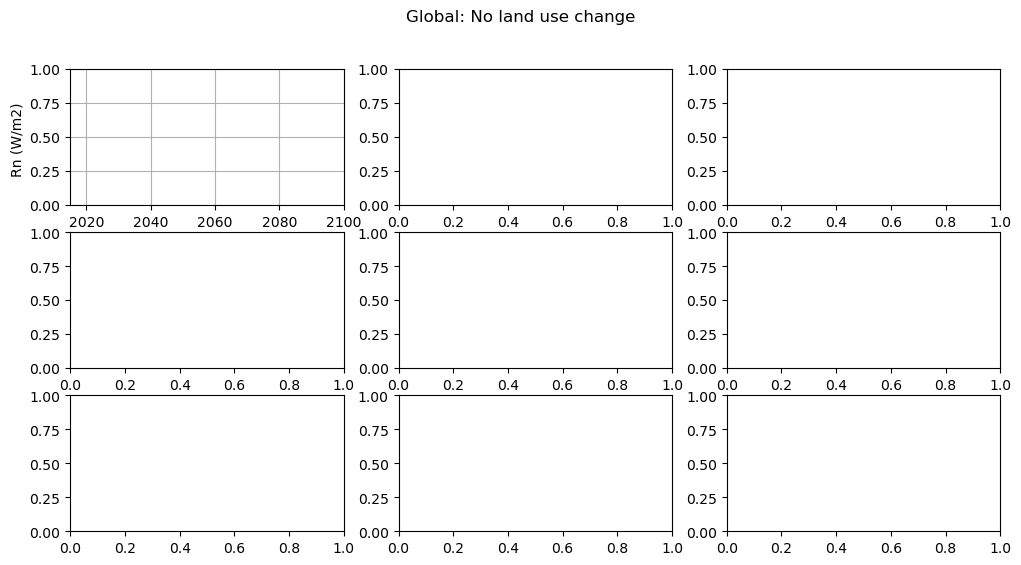

In [11]:
#ORIGINAL CODE
REGIONS=['Global','Tropics','NH-Temperate']
MODELS=['jules','clm','jsbach']
LANDUSES=['noluc','agtobio','nattobio']
SSPS=['ssp126','ssp370']
ESMS=['mpi-esm1-2-hr','ukesm1-0-ll','ipsl-cm6a-lr']
VARIABLES=['rn','hfss','hfls',\
           'hfg','rlds','rlus',\
           'rsds','rsus','TotalAlbedo']

# Note: Temperature variables for each model:
# JULES      tas, tsl (soil level), tskinpft
# JSBACH     tas, tsl
# CLM        tsl (but meta data says its tskin), and tskinpft)
# ORCHIDEE   no temperature data.

#How close can we get to energy balance for each model:
# X means it's missing
#        Rn    =   SH +    L + g          = SWdown  -  Swup      + LWdown - LWup
#JULES   rn    = hfss + hfls + X          = TotalAlbedo*(SWdown) + X      - X
#JSBACH  rn    = sfls + hfls + fGoundHeat = rsds    - rsus       + rlds   - X
#CLM     X     = hfss + rfls + hfg        = rsds    - rsus       + rlds   - rlus

years = np.arange(2015,2101)     
nyears = len(years)

LU_SCENARIO_MEAN = {var: {lsm_mod: {region: {landuse: {ssp_scen: [] for ssp_scen in SSPS} 
                    for landuse in LANDUSES} for region in REGIONS} for lsm_mod in MODELS} 
                    for var in VARIABLES}
landuse_exists = {lsm_mod: {landuse: [True] for landuse in LANDUSES} for lsm_mod in MODELS}
#landuse_exists['jsbach']['agtonat'] = False
#landuse_exists['jsbach']['nattoaff'] = False
#landuse_exists['orchidee']['agtobio'] = False
#landuse_exists['orchidee']['agtonat'] = False
#landuse_exists['orchidee']['nattobio'] = False

variable_exists = {var: {lsm_mod: [True] for lsm_mod in MODELS} for var in VARIABLES}
variable_exists['TotalAlbedo']['jsbach'] = False
variable_exists['TotalAlbedo']['clm'] = False
variable_exists['rn']['clm'] = False
variable_exists['hfg']['jules'] = False
variable_exists['rlus']['jules'] = False
variable_exists['rsus']['jules'] = False
variable_exists['rlus']['jsbach'] = False
variable_exists['rlds']['jules'] = False
#variable_exists['tas']['orchidee'] = False
#variable_exists['hfss']['jsbach'] = False
#variable_exists['pr']['clm'] = False
#variable_exists['pr']['orchidee'] = False

test_mean={ssp: [] for ssp in SSPS}
colors = {model: [] for model in MODELS}
colors['jules'] = '#F97306'
colors['clm'] = '#C5C9C7'
colors['jsbach'] = '#D1B26F'
#colors['orchidee'] = '#A9561E'
#https://matplotlib.org/stable/users/explain/colors/colors.html

linestyles = {ssp: [] for ssp in SSPS}
linestyles['ssp126'] = '-'
linestyles['ssp370'] = '--'

#cVeg and cSoil are easy

for var in VARIABLES[6:8]:
    for model in MODELS[1:2]:
        #First get no land use change (noluc)
        if variable_exists[var][model]:
            #print('Get ',var,model)
            for landuse in LANDUSES[1:]:
                if model=='jules' and landuse=='noluc':
                    landuse_name='nolucbio'
                else:
                    landuse_name=landuse
                if model=='jules' and var=='hfls':
                    varname='fHeatLatent'
                elif model=='jules' and var=='hfss':
                    varname='fHeatSensible'
                elif model=='clm' and var=='tas':
                    varname='tsl'
                elif model=='jsbach' and var=='hfss':
                    varname='sfls'
                elif model=='jsbach' and var=='hfg':
                    varname='fGroundHeat'
                else:
                    varname=var
                        
                if landuse=='noluc':
                    pickle_file=['/bdd/ESM2025/WP10/analysis/files/'+model+'_ssp126_'+var+'_'+landuse+'.pkl',\
                                 '/bdd/ESM2025/WP10/analysis/files/'+model+'_ssp370_'+var+'_'+landuse+'.pkl']
                else:
                    pickle_file=['/bdd/ESM2025/WP10/analysis/files/'+model+'_ssp126_'+var+'_'+landuse+'_BEmasked.pkl',\
                                 '/bdd/ESM2025/WP10/analysis/files/'+model+'_ssp370_'+var+'_'+landuse+'_BEmasked.pkl']
                if Path(pickle_file[0]).is_file():
                    # file exists, we can skip a bunch of steps:
                    print(landuse,'read pickle files',pickle_file[0])
                    with open(Path(pickle_file[0]), 'rb') as f1:
                        ssp126_output = pickle.load(f1)
                    with open(Path(pickle_file[1]), 'rb') as f2:
                        ssp370_output = pickle.load(f2)    
                    LU_SCENARIO_MEAN[var][model]['Global'][landuse]['ssp126'] = ssp126_output
                    LU_SCENARIO_MEAN[var][model]['Global'][landuse]['ssp370'] = ssp370_output
                    del(ssp126_output, ssp370_output)
                else:
                    #nolucaff,nolucaff_tr,nolucaff_te = retrieve_data_generic(varname,'K','nolucaff',model)
                    #nolucbio,nolucbio_tr,nolucbio_te = retrieve_data_generic(varname,'W/m2','nolucbio',model)
                    #LU_SCENARIO_MEAN[var][model]['Global']['nolucaff']['ssp126']=average_dict(nolucaff['ssp126'])
                    #LU_SCENARIO_MEAN[var][model]['Global']['nolucaff']['ssp370']=average_dict(nolucaff['ssp370'])

                    if landuse=='noluc':
                        mask_BE=False
                    else:
                        mask_BE=True
                    LU_SCENARIO_MEAN[var][model]['Global'][landuse]['ssp126'] = \
                                 get_global_biophys_noiris(varname,landuse_name,model,'ssp126',mask_BE)
                    LU_SCENARIO_MEAN[var][model]['Global'][landuse]['ssp370'] = \
                                 get_global_biophys_noiris(varname,landuse_name,model,'ssp370',mask_BE)                     
                    with open(Path(pickle_file[0]), 'wb') as f1:
                        pickle.dump(LU_SCENARIO_MEAN[var][model]['Global'][landuse]['ssp126'], f1)
                    with open(Path(pickle_file[1]), 'wb') as f2:
                        pickle.dump(LU_SCENARIO_MEAN[var][model]['Global'][landuse]['ssp126'], f2)
                print('Done with',var,model,landuse)
                
# FIRST PLOT THE NO LAND USE CHANGE SCENARIO.
icol=0
irow=0
#These will be calculated
variable_exists['TotalAlbedo']['jsbach'] = True
variable_exists['TotalAlbedo']['clm'] = True
variable_exists['rn']['clm'] = True
variable_exists['hfg']['jules'] = True
variable_exists['rsus']['jules'] = True
landuse='noluc'
#Set up plotting stuff
#Each land model needs a different color
fig,axes=plt.subplots(3,3, figsize=[12,6])
if landuse=='noluc':
    fig.suptitle('Global: No land use change',fontsize=12)
elif landuse=='agtobio':
    fig.suptitle('Global: Ag to Bio',fontsize=12)

ix=0

for var in VARIABLES:
    # set axes
    ax=axes[irow,icol]
    if var=='tas': ax.set_ylabel(r'$\Delta$' +var+' (K) ',fontsize=10)
    if var=='hfss': ax.set_ylabel('H (W/m2) ',fontsize=10)
    if var=='hfls': ax.set_ylabel('LE (W/m2) ',fontsize=10)
    if var=='hfg': ax.set_ylabel('G (W/m2) ',fontsize=10)
    if var=='rn': ax.set_ylabel('Rn (W/m2) ',fontsize=10)
    if var=='rsus': ax.set_ylabel('SWup (W/m2)',fontsize=10)
    if var=='rsds': ax.set_ylabel('SWdown (W/m2)',fontsize=10)
    if var=='rlus': ax.set_ylabel('LWup (W/m2)',fontsize=10)
    if var=='rlds': ax.set_ylabel('LWdown (W/m2)',fontsize=10)        
    if var=='TotalAlbedo': ax.set_ylabel('albedo (--) ',fontsize=10)
    ax.set_xlim([2015,2100])
    ax.grid(True) 
    
    const_val=1.0
    if var=='pr':
        const_val=86400.

#VARIABLES=['hfls','hfss','hfg','rsus','rsds','TotalAlbedo',\
#          'rlds','rlus','rn']
    
    for model in MODELS:
        if variable_exists[var][model]:
            if model=='jsbach':
                endyear=nyears-1
            else:
                endyear=nyears        
            for ssp in SSPS:
                if var =='TotalAlbedo':
                    if model=='jules':
                        # This is actually TotalAlbedo already
                        plot_noluc=(LU_SCENARIO_MEAN[var][model]['Global'][landuse][ssp]) 
                    else:
                        #Convert this to albedo. rsus has already been retreived.
                        plot_noluc = (LU_SCENARIO_MEAN['rsus'][model]['Global'][landuse][ssp]) / \
                                     (LU_SCENARIO_MEAN['rsds'][model]['Global'][landuse][ssp])
                elif var=='tas':
                    plot_noluc=LU_SCENARIO_MEAN[var][model]['Global'][landuse][ssp] - \
                               LU_SCENARIO_MEAN[var][model]['Global'][landuse][ssp][0]
                elif var=='rn' and model=='clm':
                    plot_noluc=(LU_SCENARIO_MEAN['hfss'][model]['Global'][landuse][ssp])+ \
                               (LU_SCENARIO_MEAN['hfls'][model]['Global'][landuse][ssp])+ \
                               (LU_SCENARIO_MEAN['hfg'][model]['Global'][landuse][ssp])
                elif var=='hfg' and model=='jules':
                    plot_noluc=(LU_SCENARIO_MEAN['rn'][model]['Global'][landuse][ssp])- \
                               (LU_SCENARIO_MEAN['hfls'][model]['Global'][landuse][ssp])- \
                               (LU_SCENARIO_MEAN['hfss'][model]['Global'][landuse][ssp])
                elif var=='rsus' and model=='jules':
                    plot_noluc=(LU_SCENARIO_MEAN['rsds'][model]['Global'][landuse][ssp])* \
                               (LU_SCENARIO_MEAN['TotalAlbedo'][model]['Global'][landuse][ssp])
                else:
                    plot_noluc=np.multiply((LU_SCENARIO_MEAN[var][model]['Global'][landuse][ssp]),const_val)
                
                #print(var,model)
                #print(plot_noluc,np.min(plot_noluc),np.max(plot_noluc))
                ax.plot(years[:endyear], plot_noluc, label=model+' '+ssp,
                        c=colors[model],ls=linestyles[ssp],lw=2)                
                #if var=='rsus':
                #    ax.set_ylim([40,50])

            #print(var,model,ssp,plot_noluc[-1])

                m,b = np.polyfit(years[endyear-20:endyear-1],plot_noluc[-20:-1], 1)
                print(var,model,ssp,'slope over last 20 years:',m)

    icol+=1
    if icol>2:
        icol=0
        irow+=1

ax=axes[0,0]
handles,labels = ax.get_legend_handles_labels()
fig.legend(handles,labels,ncol=2,loc='upper left',bbox_to_anchor=(0.35, 0.0),fontsize=10)
fig.tight_layout()
#ax=axes[2]
#ax.remove()
plt.savefig('/bdd/ESM2025/WP10/plots/biophys_'+landuse+'_Global.png', format="png")

In [ ]:
# ORIGINAL: PLOT THE LANDUSE SCENARIO DIFFERENCE FROM THE NOLUC SCENARIO

landuse_title=['nolucaff','noluc',' Agriculture to bioenergy', ' Natural to bioenergy', 
               ' Agriculture to afforestation', ' Agriculture to natural', ' Natural to afforestation']

plotdiff = True

# We don't need to plot all the same variables because some are the same
# regardless of the land use scenario (rlds and rsds).
# rlus is only available for one model, not interesting, and is a fx of tas
# 
VARIABLES=['TotalAlbedo','SWnet','LWnet',\
           'rn',\
           'hfss','hfls']   

#VARIABLES=['rn','SWnet','LWnet','tas']
#Note: 'tas' in CLM is actually skin T, and this makes it difficult to compare to 
# actual air temperature in JSBACH and JULES. I will remove this from the analysis
# and focus on overall change in net radiation, and how it is partitioned between 
# LE and H.
for region in REGIONS[0:1]:
    i1=2
    for landuse in LANDUSES[1:]:
     
        #Set up plotting stuff
        #Each land use scenario has a new figure
        print('new plot:',region,landuse)
        fig2,axes2=plt.subplots(2,3, figsize=[12,6])
        fig2.suptitle(region+landuse_title[i1],fontsize=12)    
        irow=0
        icol=0
        
        for var in VARIABLES:
            # set axes
            ax=axes2[irow,icol]
            if var=='tas': ax.set_ylabel(r'$\Delta$' +var+' (K) ',fontsize=10)
            if var=='hfss': ax.set_ylabel(r'$\Delta$ H (W/m2) ',fontsize=10)
            if var=='hfls': ax.set_ylabel(r'$\Delta$ LE (W/m2) ',fontsize=10)
            if var=='rn': ax.set_ylabel(r'$\Delta$ Rn (W/m2) ',fontsize=10)
            if var=='SWnet': ax.set_ylabel(r'$\Delta$ Net SW (W/m2)',fontsize=10)
            if var=='LWnet': ax.set_ylabel(r'$\Delta$ Net LW (W/m2)',fontsize=10)      
            if var=='TotalAlbedo': ax.set_ylabel(r'$\Delta$ albedo (--) ',fontsize=10)        
            
            ax.set_xlim([2015,2100])
            ax.grid(True) 
        
            for model in MODELS:
                if model=='jsbach':
                    endyear=nyears-1
                else:
                    endyear=nyears
                if model=='jules' and (landuse=='agtonat' or landuse=='agtoaff' or landuse=='nattoaff'):
                    s0='nolucaff'
                else: 
                    s0='noluc'

                
                if (landuse_exists[model][landuse]):

                    for ssp in SSPS:
                        const_val=1.0
                        if var=='pr':
                            const_val=86400.
                        if var =='TotalAlbedo':
                            if model=='jules':
                                # This is actually TotalAlbedo already
                                plot_luc=(LU_SCENARIO_MEAN[var][model][region][landuse][ssp])-\
                                        (LU_SCENARIO_MEAN[var][model][region]['noluc'][ssp])
                            else:
                                #Convert this to albedo. rsus has already been retreived.
                                plot_luc = ((LU_SCENARIO_MEAN['rsus'][model][region][landuse][ssp]) / \
                                             (LU_SCENARIO_MEAN['rsds'][model][region][landuse][ssp])) - \
                                            ((LU_SCENARIO_MEAN['rsus'][model][region]['noluc'][ssp]) / \
                                             (LU_SCENARIO_MEAN['rsds'][model][region]['noluc'][ssp]))
                        elif var=='tas':
                            plot_luc=((LU_SCENARIO_MEAN[var][model][region][landuse][ssp] - \
                                       LU_SCENARIO_MEAN[var][model][region][landuse][ssp][0])) - \
                                      ((LU_SCENARIO_MEAN[var][model][region]['noluc'][ssp] - \
                                       LU_SCENARIO_MEAN[var][model][region]['noluc'][ssp][0]))
                        elif var=='rn' and model=='clm':
                            plot_luc=((LU_SCENARIO_MEAN['hfss'][model][region][landuse][ssp])+ \
                                       (LU_SCENARIO_MEAN['hfls'][model][region][landuse][ssp])+ \
                                       (LU_SCENARIO_MEAN['hfg'][model][region][landuse][ssp])) - \
                                       ((LU_SCENARIO_MEAN['hfss'][model][region]['noluc'][ssp])+ \
                                       (LU_SCENARIO_MEAN['hfls'][model][region]['noluc'][ssp])+ \
                                       (LU_SCENARIO_MEAN['hfg'][model][region]['noluc'][ssp]))
                        elif var=='hfg' and model=='jules':
                            plot_luc=((LU_SCENARIO_MEAN['rn'][model][region][landuse][ssp])- \
                                       (LU_SCENARIO_MEAN['hfls'][model][region][landuse][ssp])- \
                                       (LU_SCENARIO_MEAN['hfss'][model][region][landuse][ssp])) - \
                                       ((LU_SCENARIO_MEAN['rn'][model][region]['noluc'][ssp])- \
                                       (LU_SCENARIO_MEAN['hfls'][model][region]['noluc'][ssp])- \
                                       (LU_SCENARIO_MEAN['hfss'][model][region]['noluc'][ssp]))  
                        elif var=='LWnet':
                            if model=='jules':
                                plot_luc = LU_SCENARIO_MEAN['rn'][model][region][landuse][ssp] - \
                                           ((1-LU_SCENARIO_MEAN['TotalAlbedo'][model][region][landuse][ssp])*\
                                            LU_SCENARIO_MEAN['rsds'][model][region][landuse][ssp]) - \
                                           (LU_SCENARIO_MEAN['rn'][model][region]['noluc'][ssp] - \
                                           ((1-LU_SCENARIO_MEAN['TotalAlbedo'][model][region]['noluc'][ssp])*\
                                            LU_SCENARIO_MEAN['rsds'][model][region]['noluc'][ssp])) 
                            elif model=='jsbach':
                               plot_luc = LU_SCENARIO_MEAN['rn'][model][region][landuse][ssp] - \
                                          (LU_SCENARIO_MEAN['rsds'][model][region][landuse][ssp]-\
                                          LU_SCENARIO_MEAN['rsus'][model][region][landuse][ssp]) - \
                                         (LU_SCENARIO_MEAN['rn'][model][region]['noluc'][ssp] - \
                                          (LU_SCENARIO_MEAN['rsds'][model][region]['noluc'][ssp]-\
                                          LU_SCENARIO_MEAN['rsus'][model][region]['noluc'][ssp])) 
                            elif model=='clm': 
                                #I have checked below: first term (rlds) is 0, second term (rlus)
                                # is negative; net change is increased LW absorbed at sfc.
                               plot_luc = (LU_SCENARIO_MEAN['rlds'][model][region][landuse][ssp] - \
                                          LU_SCENARIO_MEAN['rlds'][model][region]['noluc'][ssp]) - \
                                          (LU_SCENARIO_MEAN['rlus'][model][region][landuse][ssp] - \
                                          LU_SCENARIO_MEAN['rlus'][model][region]['noluc'][ssp])
                                          #(LU_SCENARIO_MEAN['rlds'][model][region][landuse][ssp]-\
                                          #  LU_SCENARIO_MEAN['rlus'][model][region][landuse][ssp]) - \
                                           # LU_SCENARIO_MEAN['rlus'][model][region]['noluc'][ssp])
                                          ##(LU_SCENARIO_MEAN['rlds'][model][region]['noluc'][ssp]-\
                        elif var=='SWnet':
                            if model=='jules':
                                plot_luc = ((1-LU_SCENARIO_MEAN['TotalAlbedo'][model][region][landuse][ssp])*\
                                            LU_SCENARIO_MEAN['rsds'][model][region][landuse][ssp]) - \
                                           ((1-LU_SCENARIO_MEAN['TotalAlbedo'][model][region]['noluc'][ssp])*\
                                            LU_SCENARIO_MEAN['rsds'][model][region]['noluc'][ssp]) 
                            else:
                               plot_luc = (LU_SCENARIO_MEAN['rsds'][model][region][landuse][ssp]-\
                                            LU_SCENARIO_MEAN['rsus'][model][region][landuse][ssp]) - \
                                          (LU_SCENARIO_MEAN['rsds'][model][region]['noluc'][ssp]-\
                                            LU_SCENARIO_MEAN['rsus'][model][region]['noluc'][ssp])                            
                        else:
                            plot_luc=(LU_SCENARIO_MEAN[var][model][region][landuse][ssp])-\
                                    (LU_SCENARIO_MEAN[var][model][region]['noluc'][ssp])
                
                        if model=='clm':
                            ax.plot(years[2:endyear], plot_luc[2:], label=model+' '+ssp,
                                c=colors[model],ls=linestyles[ssp],lw=2)
                        else:
                            ax.plot(years[:endyear], plot_luc, label=model+' '+ssp,
                                c=colors[model],ls=linestyles[ssp],lw=2)
                        #print(var,model,ssp,plot_luc[-1])

                        #m,b = np.polyfit(years[endyear-20:endyear-1],plot_noluc[-20:-1], 1)
                        #print(var,model,ssp,'slope over last 20 years:',m)

            icol+=1
            if icol>2:
                icol=0
                irow+=1
                    
        i1+=1

        ax=axes[0,0]
        handles2,labels2 = ax.get_legend_handles_labels()
        fig2.legend(handles2,labels2,ncol=2,loc='upper left',bbox_to_anchor=(0.40, 0.00),\
                    frameon=False,fontsize=10)
        fig2.tight_layout()
        #ax=axes2[2]
        #ax.remove()
        
        if plotdiff:
            plt.savefig('/bdd/ESM2025/WP10/plots/biophys_'+landuse+'-noluc_'+region+'.png', format="png")
        else:
            plt.savefig('/bdd/ESM2025/WP10/plots/biophys_'+landuse+'_'+region+'.png', format="png")